
Gerando gráfico para BENTO GONCALVES (Arquivo: dados_A840_H_2023-09-01_2023-09-06.csv)...


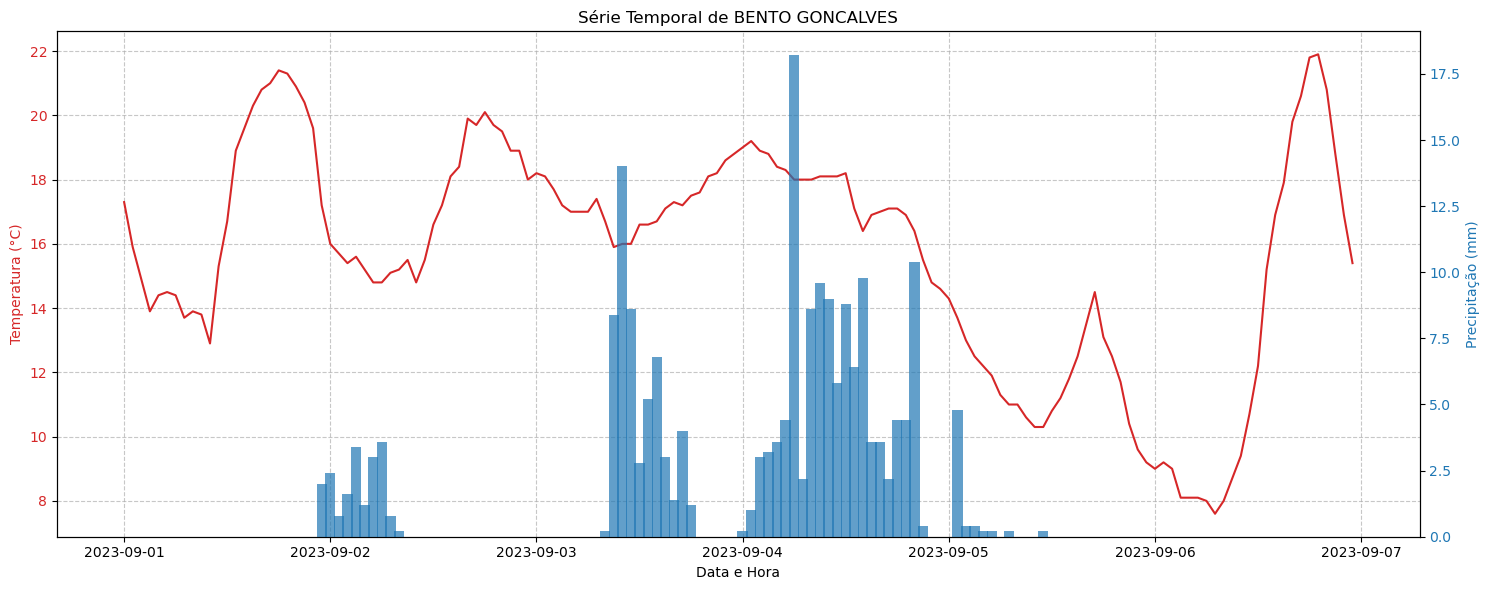

In [1]:

import pandas as pd
import matplotlib.pyplot as plt

# Painel de Control (Configurações e Ação Manual)
LINHAS_PARA_PULAR_DADOS = 10
COLUNA_TEMP = 'TEMPERATURA DO AR - BULBO SECO, HORARIA(°C)'
COLUNA_PREC = 'PRECIPITACAO TOTAL, HORARIO(mm)'
VALORES_NULOS = [-9999, '-9999', 'null']
CODIFICACAO = 'utf-8'

ARQUIVO_PARA_PLOTAR = 'dados_A840_H_2023-09-01_2023-09-06.csv'
NOME_DA_ESTACAO = 'BENTO GONCALVES' # (Nome para o título)

print(f"\nGerando gráfico para {NOME_DA_ESTACAO} (Arquivo: {ARQUIVO_PARA_PLOTAR})...")

df_plot = pd.read_csv(
    ARQUIVO_PARA_PLOTAR, sep=';', skiprows=LINHAS_PARA_PULAR_DADOS,
    na_values=VALORES_NULOS, encoding=CODIFICACAO, engine='python'
)

hora_texto = df_plot['Hora Medicao'].astype(str)
hora_texto = hora_texto.str.zfill(4) # Garante 4 dígitos (ex: "100" vira "0100")
data_texto = df_plot['Data Medicao'].astype(str)


df_plot['datetime'] = pd.to_datetime(
    data_texto + ' ' + hora_texto,
    format='%Y-%m-%d %H%M' # (Formato: Ano-Mês-Dia HoraMinuto)
)

# 3.4. Garante que as colunas de dados são numéricas
df_plot[COLUNA_TEMP] = pd.to_numeric(df_plot[COLUNA_TEMP], errors='coerce')
df_plot[COLUNA_PREC] = pd.to_numeric(df_plot[COLUNA_PREC], errors='coerce')

# Geração do Gráfico (com 2 eixos Y)
fig, ax1 = plt.subplots(figsize=(15, 6))

cor_temp = 'tab:red'
ax1.set_xlabel('Data e Hora')
ax1.set_ylabel('Temperatura (°C)', color=cor_temp)
ax1.plot(df_plot['datetime'], df_plot[COLUNA_TEMP], color=cor_temp, label='Temperatura')
ax1.tick_params(axis='y', labelcolor=cor_temp)
ax1.grid(linestyle='--', alpha=0.7)


ax2 = ax1.twinx()

cor_prec = 'tab:blue'
ax2.set_ylabel('Precipitação (mm)', color=cor_prec)
ax2.bar(df_plot['datetime'], df_plot[COLUNA_PREC], color=cor_prec, label='Precipitação', width=0.05, alpha=0.7)
ax2.tick_params(axis='y', labelcolor=cor_prec)

plt.title(f"Série Temporal de {NOME_DA_ESTACAO}")
fig.tight_layout()
plt.show()

